In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

RNG_SEED = 42
MAX_ITERATIONS = 10
LEARNING_RATE = 1.0

COLOR_CLASS_1 = "#7648f4"
COLOR_CLASS_0 = "#ef77a7"
COLOR_BOUNDARY = "#fbedc0"

In [35]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)


def bce_loss(y_true, y_pred_proba):
    eps = 1e-12
    p = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


def to_raw_space(w, b, mu, sigma):
    w_raw = w / sigma
    b_raw = b - np.sum(w * mu / sigma)
    return w_raw, b_raw


def train_neuron(X, y, w, b, iterations, lr):
    history = []
    n = X.shape[0]

    for epoch in range(iterations):
        proba = predict_proba(X, w, b)
        loss = bce_loss(y, proba)
        history.append(loss)

        error = proba - y
        grad_w = (X.T @ error) / n
        grad_b = np.mean(error)

        w -= lr * grad_w
        b -= lr * grad_b

        print(f"Epoch {epoch+1}/{iterations}  Loss = {loss:.4f}")

    return w, b, history

In [36]:
def plot_decision_boundary(X, y, w, b, title, filename=None):

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection="3d")

    mask1 = y == 1
    mask0 = y == 0

    ax.scatter(
        X[mask1,0], X[mask1,1], X[mask1,2],
        c=COLOR_CLASS_1,
        marker="o",
        s=60,
        label="Class 1",
        edgecolor="white"
    )

    ax.scatter(
        X[mask0,0], X[mask0,1], X[mask0,2],
        c=COLOR_CLASS_0,
        marker="^",
        s=60,
        label="Class 0",
        edgecolor="white"
    )

    u1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 10)
    u2 = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 10)

    U1, U2 = np.meshgrid(u1, u2)

    if abs(w[2]) > 1e-8:
        U3 = -(w[0]*U1 + w[1]*U2 + b)/w[2]
        ax.plot_surface(U1, U2, U3,
                        color=COLOR_BOUNDARY,
                        alpha=0.3)

    ax.set_xlabel("u1")
    ax.set_ylabel("u2")
    ax.set_zlabel("u3")
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=150)

    plt.show()

In [37]:
def plot_confusion_matrix(cm, filename=None):

    fig, ax = plt.subplots(figsize=(4.5,4))

    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticklabels(["True 0","True 1"])

    ax.set_title("Confusion Matrix")

    vmax = cm.max()

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i,j] > vmax/2 else "black"

            ax.text(
                j, i,
                str(cm[i,j]),
                ha="center",
                va="center",
                fontsize=14,
                color=color
            )

    fig.colorbar(im)

    plt.tight_layout()

    if filename:
        fig.savefig(filename, dpi=150)

    plt.show()

In [38]:
df = pd.read_csv("neuron_dataset.csv", sep=";")

X = df[["u1","u2","u3"]].to_numpy(dtype=float)
y = df["label"].to_numpy(dtype=float)

df.head()

,u1,u2,u3,label
0,1,1,1,1
1,1,2,1,1
2,2,1,2,1
3,2,2,1,1
4,4,1,1,1


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RNG_SEED,
    stratify=y
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples : {len(X_test)}")

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

Train samples: 68
Test samples : 30


In [40]:
rng = np.random.default_rng(RNG_SEED)

w = rng.normal(scale=0.1, size=3)
b = 0.0

print("Initial weights:", w)
print("Initial bias:", b)

Initial weights: [ 0.03047171 -0.10399841  0.07504512]
Initial bias: 0.0


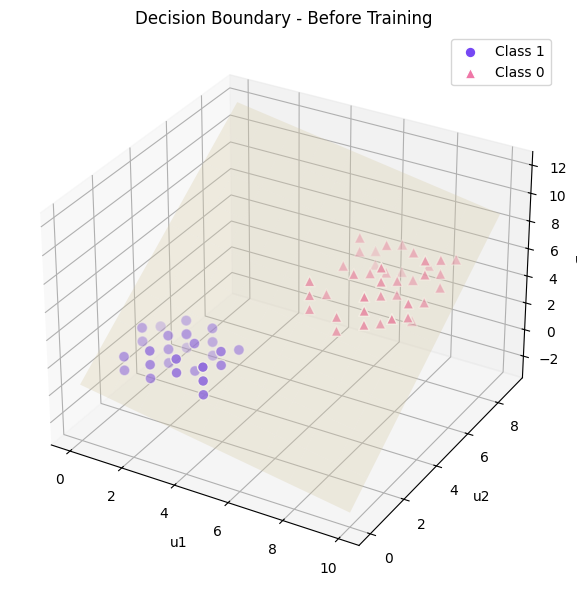

In [41]:
w_raw, b_raw = to_raw_space(w, b, mu, sigma)

plot_decision_boundary(
    X_train,
    y_train,
    w_raw,
    b_raw,
    "Decision Boundary - Before Training",
    "decision_boundary_initial.png"
)

In [42]:
w, b, history = train_neuron(
    X_train_s,
    y_train,
    w,
    b,
    MAX_ITERATIONS,
    LEARNING_RATE
)

Epoch 1/10  Loss = 0.6960
Epoch 2/10  Loss = 0.2909
Epoch 3/10  Loss = 0.1945
Epoch 4/10  Loss = 0.1499
Epoch 5/10  Loss = 0.1236
Epoch 6/10  Loss = 0.1060
Epoch 7/10  Loss = 0.0932
Epoch 8/10  Loss = 0.0835
Epoch 9/10  Loss = 0.0759
Epoch 10/10  Loss = 0.0697


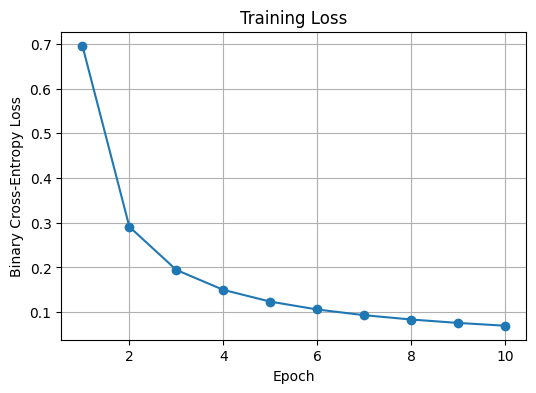

In [43]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(history)+1), history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

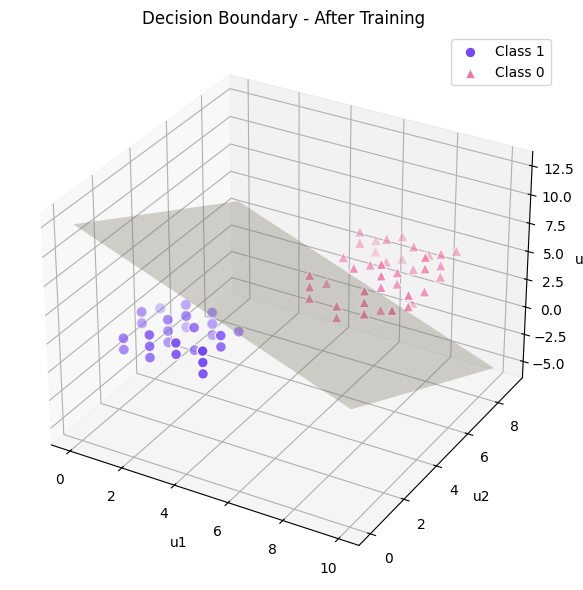

In [44]:
w_raw, b_raw = to_raw_space(w, b, mu, sigma)

plot_decision_boundary(
    X_train,
    y_train,
    w_raw,
    b_raw,
    "Decision Boundary - After Training",
    "decision_boundary_final.png"
)

In [45]:
y_pred = predict(X_test_s, w, b)

cm = confusion_matrix(y_test, y_pred, labels=[0,1])

print(cm)

accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {accuracy:.2f}")

[[18  0]
 [ 0 12]]
Accuracy: 1.00


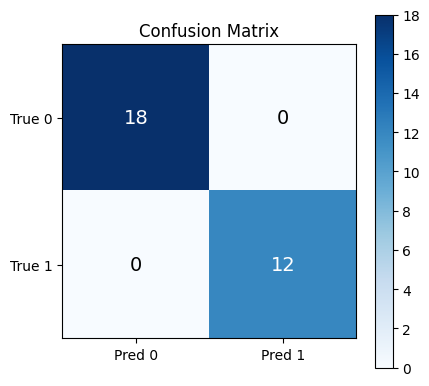

In [46]:
plot_confusion_matrix(
    cm,
    "confusion_matrix.png"
)

In [47]:
print("Weights (standardized):")
print(w)

print("\nBias:")
print(b)

print("\nWeights (raw space):")
print(w_raw)

print("\nRaw bias:")
print(b_raw)

Weights (standardized):
[-1.24972688 -1.18956158 -1.09261087]

Bias:
-0.43443577720180604

Weights (raw space):
[-0.45858926 -0.52307101 -0.52574424]

Raw bias:
6.5451913135963125


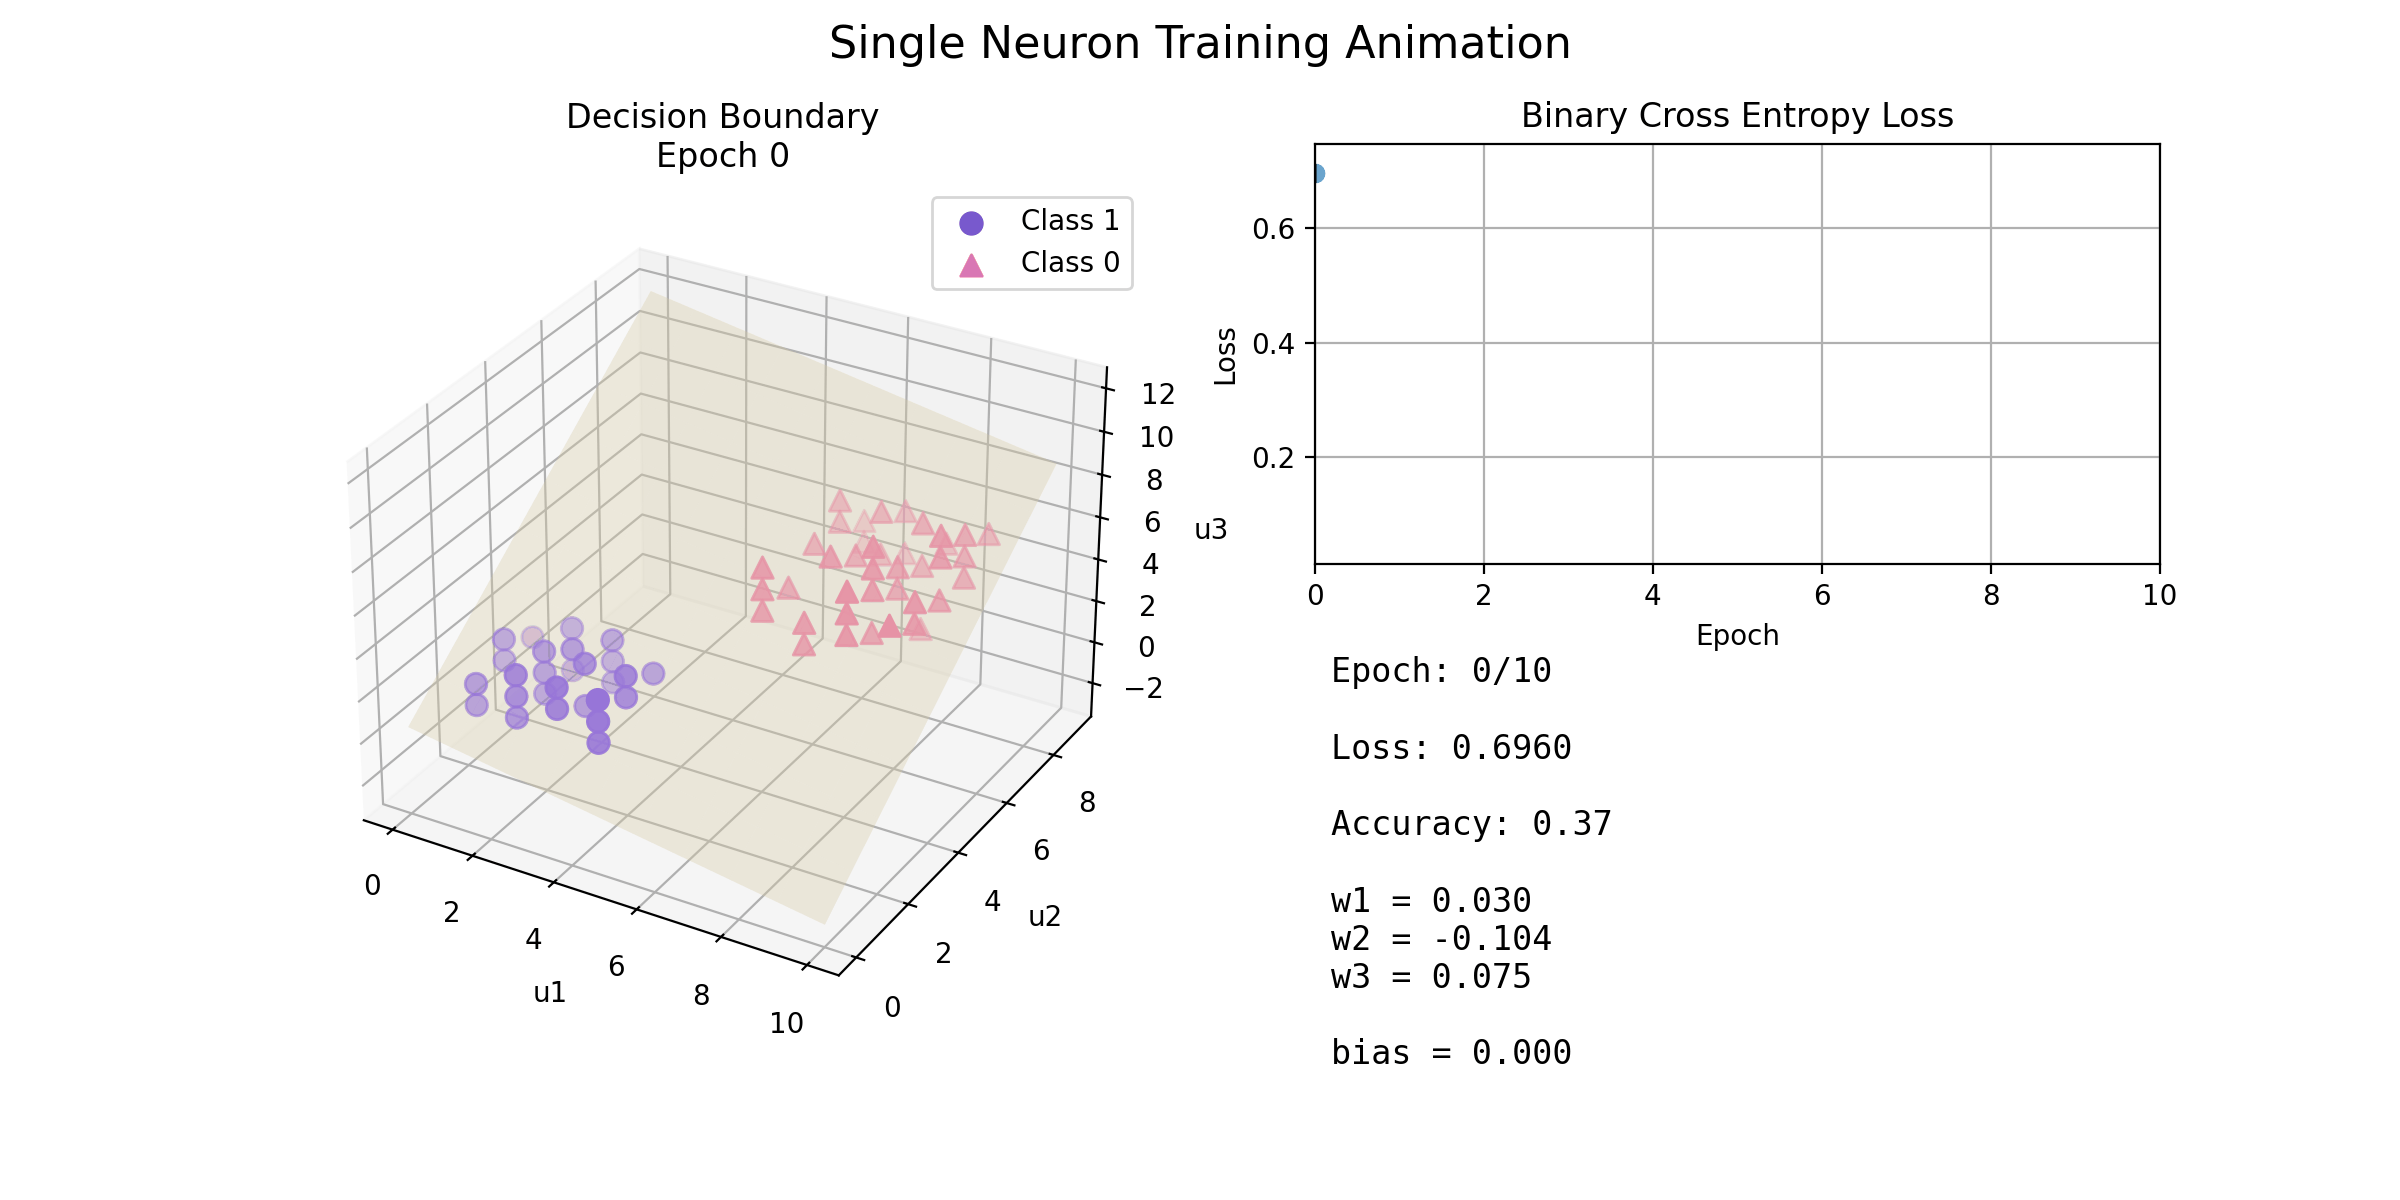

In [ ]:
from IPython.display import Image, display

display(Image('neuron_training.gif'))